<a href="https://colab.research.google.com/github/SakshyamAryal077/CADWORK/blob/main/ACSVISUALIZE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#USE THIS BLOCK TO IMPORT AND LOAD THE MODEL AND DATASET



# Mount Drive
#      ↓
# Set paths/imports
#      ↓
# Clone ECG-FoUNDer repository
#      ↓
# Load checkpoint from Drive
#      ↓
# Ready



# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

# Project paths
PROJECT_DIR = "/content/drive/MyDrive/ECG_Project"

CHECKPOINT = os.path.join(
    PROJECT_DIR,
    "checkpoints",
    "12_lead_ECGFounder.pth"
)

ACS_DIR = os.path.join(
    PROJECT_DIR,
    "ACS19955"
)

CSV_DIR = os.path.join(
    ACS_DIR,
    "CSV",
    "CSV"
)

ECG_DIR = os.path.join(
    ACS_DIR,
    "ECG_row_data",
    "row_data"
)

print("✅ Drive mounted")
print("✅ ECG-FoUNDer:", os.path.exists(CHECKPOINT))
print("✅ ACS dataset:", os.path.exists(ACS_DIR))
print("✅ CSV:", os.path.exists(CSV_DIR))
print("✅ ECG data:", os.path.exists(ECG_DIR))



!git clone -q https://github.com/PKUDigitalHealth/ECGFounder.git /content/ECGFounder
%cd /content/ECGFounder



from net1d import Net1D

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Net1D(
    in_channels=12,
    base_filters=64,
    ratio=1,
    filter_list=[64,160,160,400,400,1024,1024],
    m_blocks_list=[2,2,2,3,3,4,4],
    kernel_size=16,
    stride=2,
    groups_width=16,
    verbose=False,
    use_bn=False,
    use_do=False,
    n_classes=150
)

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["state_dict"], strict=False)
model.to(device)
model.eval()

print("✅ ECG-FoUNDer loaded on", device)

Mounted at /content/drive
✅ Drive mounted
✅ ECG-FoUNDer: True
✅ ACS dataset: True
✅ CSV: True
✅ ECG data: True
/content/ECGFounder
✅ ECG-FoUNDer loaded on cpu


In [ ]:
import os
import pandas as pd

print(os.listdir(CSV_DIR))

['test.csv', 'train.csv']


In [ ]:
for file in os.listdir(CSV_DIR):
    path = os.path.join(CSV_DIR, file)

    print("\nFILE:", file)
    df = pd.read_csv(path)

    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print("\nFirst 3 rows:")
    display(df.head(3))


FILE: test.csv
Shape: (1995, 6)
Columns:
['Patient_id', 'ecg_row_record', 'ecg_med_record', 'gender', 'age', 'Time_Interval']

First 3 rows:


,Patient_id,ecg_row_record,ecg_med_record,gender,age,Time_Interval
0,P00010,16210.dat,16210.med,1,52,1797
1,P00012,12576.dat,12576.med,0,75,130
2,P00014,01158.dat,01158.med,1,71,171



FILE: train.csv
Shape: (17960, 28)
Columns:
['Patient_id', 'ecg_row_record', 'ecg_med_record', 'gender', 'age', 'Time_Interval', 'AMI', 'OMI', 'CTO', 'PCI', 'NSTEMI', 'STEMI', 'UA', 'LM', 'PLAD', 'MLAD', 'DLAD', 'DB', 'PLCX', 'MLCX', 'DLCX', 'OM', 'PRCA', 'MRCA', 'DRCA', 'VF_VT', 'Paced', 'Prior_PCI']

First 3 rows:


,Patient_id,ecg_row_record,ecg_med_record,gender,age,Time_Interval,AMI,OMI,CTO,PCI,...,PLCX,MLCX,DLCX,OM,PRCA,MRCA,DRCA,VF_VT,Paced,Prior_PCI
0,P00001,04904.dat,04904.med,1,58,67,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,P00002,15878.dat,15878.med,1,68,2895,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,P00002,13502.dat,13502.med,1,67,1633,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_df = pd.read_csv(
    "/content/drive/MyDrive/ECG_Project/ACS19955/CSV/CSV/train.csv"
)

label_cols = [
    'AMI', 'OMI', 'CTO', 'PCI',
    'NSTEMI', 'STEMI', 'UA',
    'LM', 'PLAD', 'MLAD', 'DLAD',
    'PLCX', 'MLCX', 'DLCX', 'OM',
    'PRCA', 'MRCA', 'DRCA',
    'VF_VT', 'Paced', 'Prior_PCI'
]

for col in label_cols:
    print(f"{col:10s}: {train_df[col].sum():5d} "
          f"({train_df[col].mean()*100:.2f}%)")

AMI       :  2679 (14.92%)
OMI       :  1151 (6.41%)
CTO       :   957 (5.33%)
PCI       :  4541 (25.28%)
NSTEMI    :  1235 (6.88%)
STEMI     :  1442 (8.03%)
UA        :  6213 (34.59%)
LM        :    13 (0.07%)
PLAD      :   838 (4.67%)
MLAD      :   332 (1.85%)
DLAD      :    44 (0.24%)
PLCX      :   400 (2.23%)
MLCX      :   226 (1.26%)
DLCX      :   255 (1.42%)
OM        :    53 (0.30%)
PRCA      :   720 (4.01%)
MRCA      :   456 (2.54%)
DRCA      :   357 (1.99%)
VF_VT     :   869 (4.84%)
Paced     :   338 (1.88%)
Prior_PCI :  1323 (7.37%)


In [ ]:
patient = train_df[train_df["Patient_id"] == "P00002"]

display(patient)

,Patient_id,ecg_row_record,ecg_med_record,gender,age,Time_Interval,AMI,OMI,CTO,PCI,...,PLCX,MLCX,DLCX,OM,PRCA,MRCA,DRCA,VF_VT,Paced,Prior_PCI
1,P00002,15878.dat,15878.med,1,68,2895,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,P00002,13502.dat,13502.med,1,67,1633,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
row = train_df.iloc[0]

print("Patient:", row["Patient_id"])
print("ECG file:", row["ecg_row_record"])

print("\nLabels:")
for col in label_cols:
    if row[col] == 1:
        print("  ✓", col)

Patient: P00001
ECG file: 04904.dat

Labels:


In [ ]:
ecg_file = os.path.join(
    ECG_DIR,
    row["ecg_row_record"]
)

print(ecg_file)
print(os.path.exists(ecg_file))

/content/drive/MyDrive/ECG_Project/ACS19955/ECG_row_data/row_data/04904.dat
False


In [ ]:
!pip install wfdb
import wfdb
import matplotlib.pyplot as plt
import numpy as np

ecg_path = "/content/drive/MyDrive/ECG_Project/ACS19955/ECG_row_data/row_data/04904"

signals, fields = wfdb.rdsamp(ecg_path)

print("Shape:", signals.shape)
print("Sampling frequency:", fields["fs"])
print("Duration:", signals.shape[0] / fields["fs"], "seconds")
print("Leads:", fields["sig_name"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.7 MB/s eta 0:00:00
Shape: (5000, 12)
Sampling frequency: 500
Duration: 10.0 seconds
Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


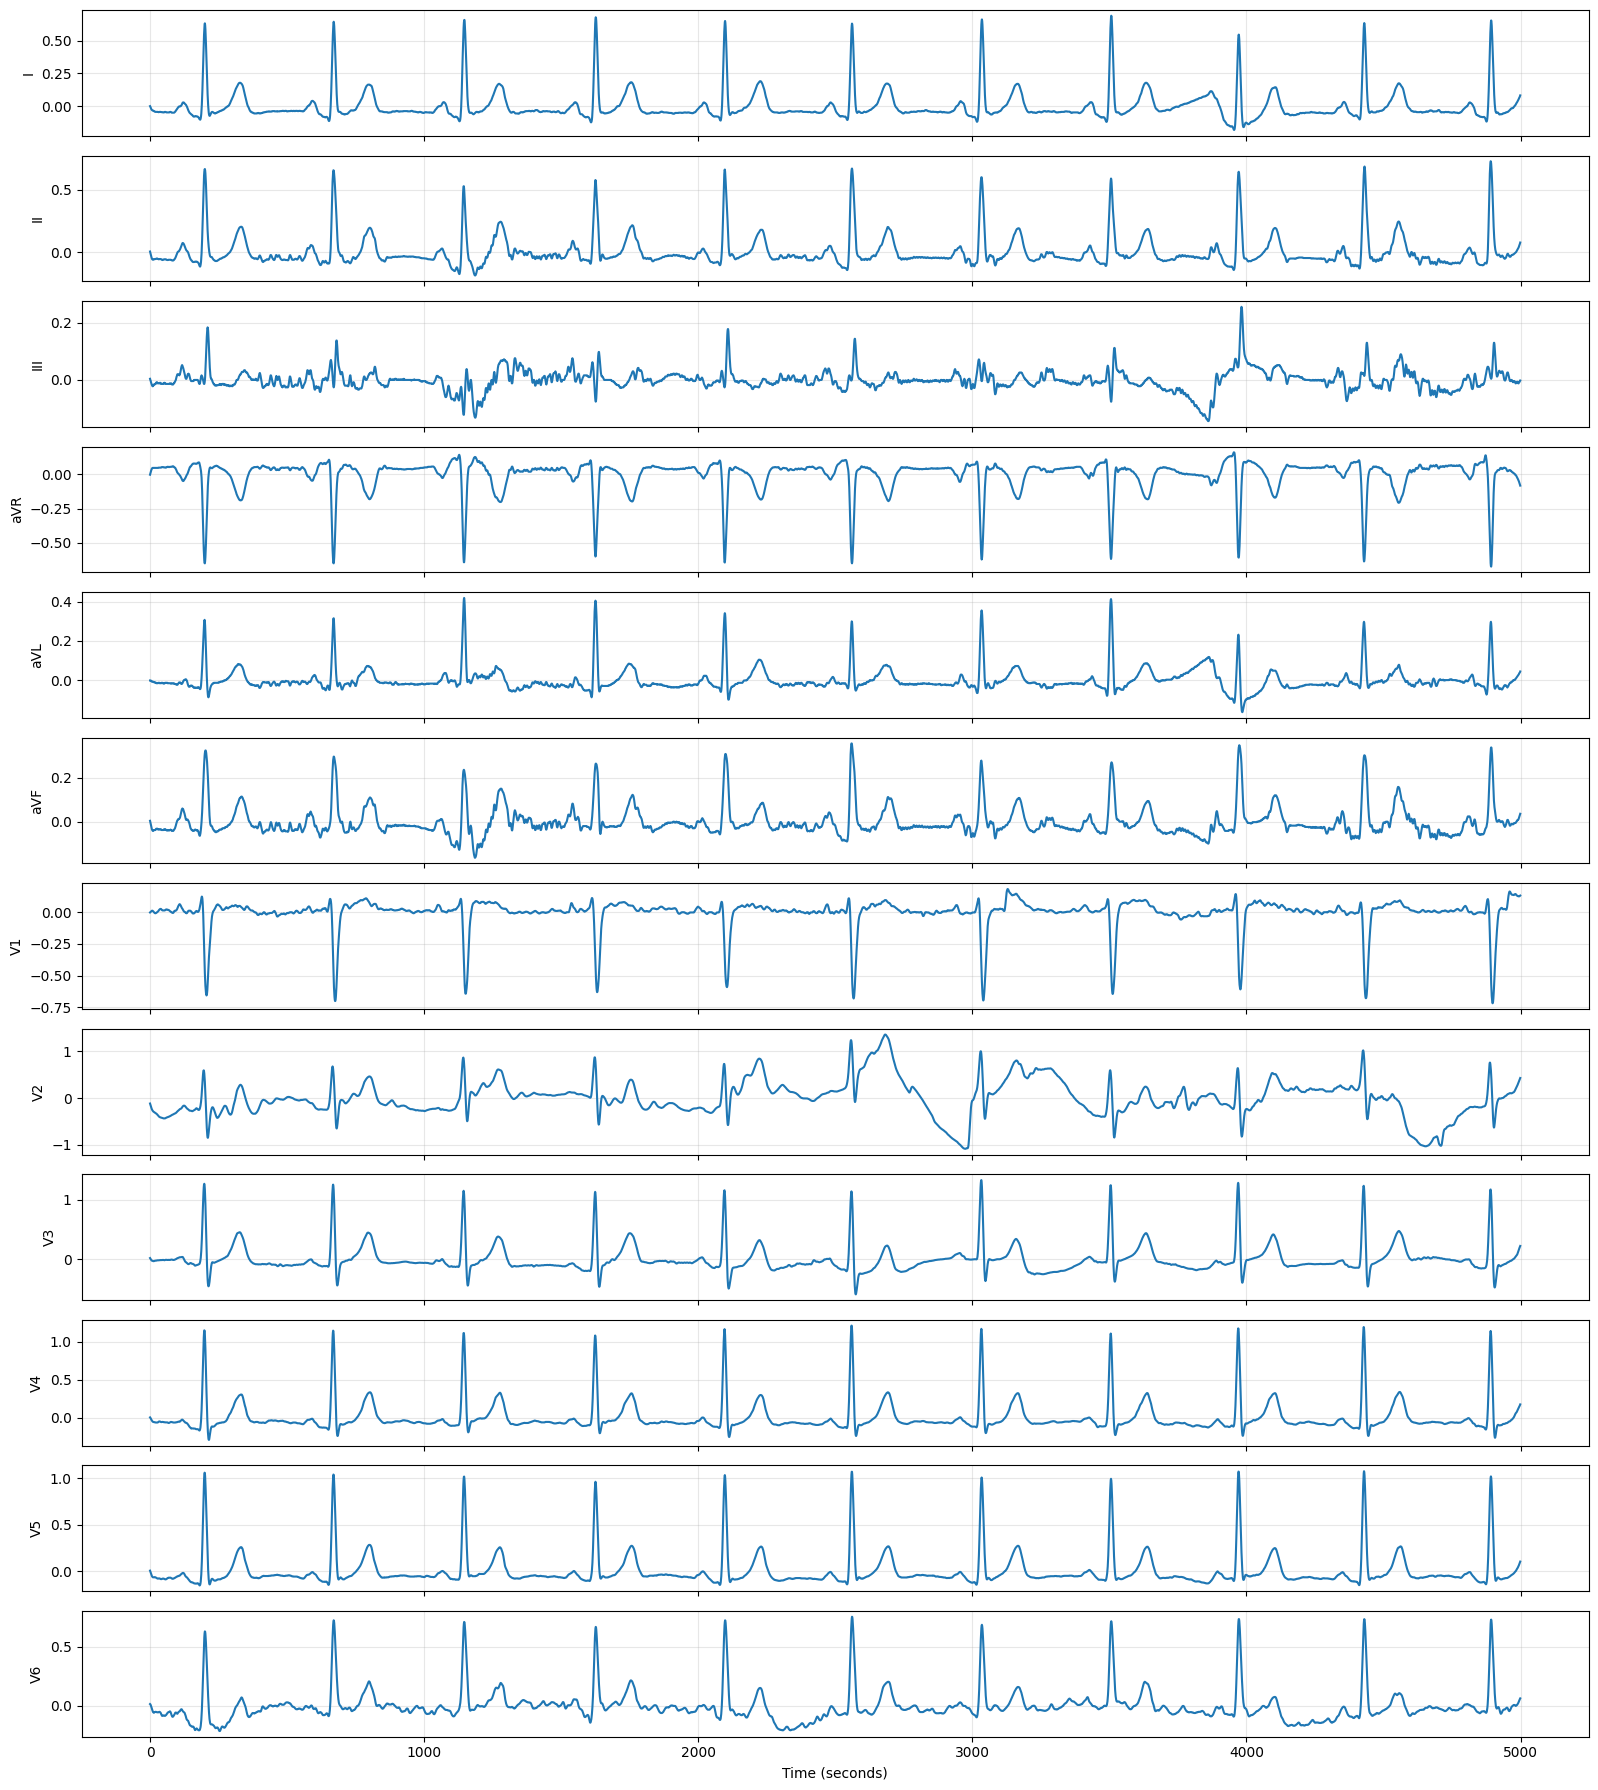

In [ ]:
fig, axes = plt.subplots(12, 1, figsize=(16, 18), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(signals[:, i])
    ax.set_ylabel(fields["sig_name"][i])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

Preprocessing Code For ECG FOUNDER MODEL

In [ ]:
import numpy as np
import torch
import wfdb

from scipy.signal import iirnotch, butter, filtfilt, medfilt


def preprocess_ecg(ecg_path, fs=500):

    # Load ECG
    data, metadata = wfdb.rdsamp(ecg_path)

    # (5000, 12) → (12, 5000)
    data = data.T

    # Replace NaN
    data = np.nan_to_num(data, nan=0.0)

    # ------------------------------------------------
    # 1. 50 Hz notch filter
    # ------------------------------------------------
    b, a = iirnotch(50, 30, fs)

    filtered = np.zeros_like(data)

    for c in range(data.shape[0]):
        filtered[c] = filtfilt(b, a, data[c])

    # ------------------------------------------------
    # 2. Butterworth bandpass: 0.67–40 Hz
    # ------------------------------------------------
    b, a = butter(
        N=4,
        Wn=[0.67, 40],
        btype="bandpass",
        fs=fs
    )

    for c in range(data.shape[0]):
        filtered[c] = filtfilt(b, a, filtered[c])

    # ------------------------------------------------
    # 3. Baseline wander removal
    # ------------------------------------------------
    kernel_size = int(0.4 * fs) + 1

    if kernel_size % 2 == 0:
        kernel_size += 1

    baseline = np.zeros_like(filtered)

    for c in range(filtered.shape[0]):
        baseline[c] = medfilt(
            filtered[c],
            kernel_size=kernel_size
        )

    filtered = filtered - baseline

    # ------------------------------------------------
    # 4. Global Z-score normalization
    # ------------------------------------------------
    filtered = (
        filtered - np.mean(filtered)
    ) / (
        np.std(filtered) + 1e-8
    )

    # Convert to PyTorch tensor
    tensor = torch.tensor(
        filtered,
        dtype=torch.float32
    )

    return tensor

In [ ]:
ecg_path = "/content/drive/MyDrive/ECG_Project/ACS19955/ECG_row_data/row_data/04904"

x = preprocess_ecg(ecg_path)

print("Shape:", x.shape)
print("Mean:", x.mean().item())
print("Std:", x.std().item())
print("Min:", x.min().item())
print("Max:", x.max().item())

Shape: torch.Size([12, 5000])
Mean: 1.0172526154761385e-09
Std: 1.000008225440979
Min: -5.325092315673828
Max: 9.077710151672363


In [ ]:
x_batch = x.unsqueeze(0).to(device)

print(x_batch.shape)

torch.Size([1, 12, 5000])


In [ ]:
model.eval()

with torch.no_grad():
    logits = model(x_batch)
    probabilities = torch.sigmoid(logits)

print("Logits shape:", logits.shape)
print("Probability shape:", probabilities.shape)

Logits shape: torch.Size([1, 150])
Probability shape: torch.Size([1, 150])


In [ ]:
with open("/content/ECGFounder/tasks.txt") as f:
    tasks = [line.strip() for line in f if line.strip()]

probs = probabilities[0].cpu().numpy()

top_indices = np.argsort(probs)[::-1][:20]

for idx in top_indices:
    print(f"{idx:3d} | {probs[idx]:.4f} | {tasks[idx]}")

  3 | 0.9991 | SINUS RHYTHM
  1 | 0.9990 | NORMAL SINUS RHYTHM
  2 | 0.9678 | NORMAL ECG
  0 | 0.2000 | ABNORMAL ECG
 15 | 0.1904 | LOW VOLTAGE QRS
  7 | 0.1297 | otherwise normal ecg
 29 | 0.1012 | QT HAS SHORTENED
  9 | 0.1001 | PREMATURE VENTRICULAR COMPLEXES
 10 | 0.0944 | BORDERLINE ECG
 13 | 0.0943 | LEFT ATRIAL ENLARGEMENT
  5 | 0.0849 | ATRIAL FIBRILLATION
 14 | 0.0822 | NONSPECIFIC T WAVE ABNORMALITY
 22 | 0.0810 | NONSPECIFIC T WAVE ABNORMALITY NO LONGER EVIDENT IN
 45 | 0.0777 | ST NO LONGER DEPRESSED IN
 25 | 0.0749 | NONSPECIFIC ST ABNORMALITY
 69 | 0.0677 | PREMATURE ECTOPIC COMPLEXES
 27 | 0.0638 | T WAVE INVERSION NO LONGER EVIDENT IN
 32 | 0.0586 | ATRIAL FLUTTER
 31 | 0.0546 | FUSION COMPLEXES
 19 | 0.0491 | PREMATURE SUPRAVENTRICULAR COMPLEXES


In [ ]:
import pandas as pd
import os

acs_dir = "/content/drive/MyDrive/ECG_Project/ACS19955"

train_csv = os.path.join(acs_dir, "CSV", "CSV", "train.csv")

train_df = pd.read_csv(train_csv)

print("Dataset shape:", train_df.shape)
print(train_df.head())

Dataset shape: (17960, 28)
  Patient_id ecg_row_record ecg_med_record  gender  age  Time_Interval  AMI  \
0     P00001      04904.dat      04904.med       1   58             67    0   
1     P00002      15878.dat      15878.med       1   68           2895    0   
2     P00002      13502.dat      13502.med       1   67           1633    0   
3     P00003      02934.dat      02934.med       1   57            440    0   
4     P00004      12776.dat      12776.med       1   25            232    0   

   OMI  CTO  PCI  ...  PLCX  MLCX  DLCX  OM  PRCA  MRCA  DRCA  VF_VT  Paced  \
0    0    0    0  ...     0     0     0   0     0     0     0      0      0   
1    0    0    1  ...     0     0     0   0     0     0     0      0      0   
2    0    0    1  ...     0     0     0   0     0     0     0      0      0   
3    0    0    1  ...     0     0     0   0     0     0     0      0      0   
4    0    0    0  ...     0     0     0   0     0     0     0      0      0   

   Prior_PCI  
0       

In [ ]:
acs_labels = [
    'AMI',
    'OMI',
    'CTO',
    'PCI',
    'NSTEMI',
    'STEMI',
    'UA',
    'LM',
    'PLAD',
    'MLAD',
    'DLAD',
    'DB',
    'PLCX',
    'MLCX',
    'DLCX',
    'OM',
    'PRCA',
    'MRCA',
    'DRCA',
    'VF_VT',
    'Paced',
    'Prior_PCI'
]

print(len(acs_labels))

22


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
import wfdb

class ACS19955Dataset(Dataset):

    def __init__(self, dataframe, ecg_dir):

        self.df = dataframe.reset_index(drop=True)
        self.ecg_dir = ecg_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # ECG filename
        filename = row["ecg_row_record"].replace(".dat", "")

        ecg_path = os.path.join(
            self.ecg_dir,
            filename
        )

        # Load ECG
        data, metadata = wfdb.rdsamp(ecg_path)

        # (5000, 12) → (12, 5000)
        data = data.T

        # NaN handling
        data = np.nan_to_num(data, nan=0.0)

        # ECG-FoUNDer preprocessing
        data = filter_bandpass(data, 500)

        # Z-score
        data = (
            data - np.mean(data)
        ) / (
            np.std(data) + 1e-8
        )

        # Convert to tensor
        signal = torch.tensor(
            data,
            dtype=torch.float32
        )

        # ACS labels
        labels = row[acs_labels].values.astype(np.float32)

        labels = torch.tensor(
            labels,
            dtype=torch.float32
        )

        return signal, labels

In [ ]:
ecg_dir = os.path.join(
    acs_dir,
    "ECG_row_data",
    "row_data"
)

acs_dataset = ACS19955Dataset(
    train_df,
    ecg_dir
)

print("Number of ECGs:", len(acs_dataset))

Number of ECGs: 17960


In [ ]:
from util import filter_bandpass
signal, labels = acs_dataset[0]

print("Signal shape:", signal.shape)
print("Labels shape:", labels.shape)

print("\nLabels:")
for name, value in zip(acs_labels, labels):
    if value == 1:
        print(name)

Signal shape: torch.Size([12, 5000])
Labels shape: torch.Size([22])

Labels:


In [ ]:
from torch.utils.data import DataLoader

small_dataset = torch.utils.data.Subset(
    acs_dataset,
    range(100)
)

loader = DataLoader(
    small_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Batches:", len(loader))

Batches: 13


In [ ]:
import os

acs_dir = "/content/drive/MyDrive/ECG_Project/ACS19955"

print(os.listdir(acs_dir))

['CSV.zip', 'ECG_row_data.zip', 'CSV', 'ECG_row_data', 'preprocessed']


In [ ]:
import os
import pandas as pd

acs_dir = "/content/drive/MyDrive/ECG_Project/ACS19955"

train_csv = os.path.join(acs_dir, "CSV", "CSV", "train.csv")
test_csv  = os.path.join(acs_dir, "CSV", "CSV", "test.csv")

print(os.path.exists(train_csv))
print(os.path.exists(test_csv))

print("ECG directory:", ecg_dir)
print("Train CSV exists:", os.path.exists(train_csv))
print("Test CSV exists:", os.path.exists(test_csv))

True
True
ECG directory: /content/drive/MyDrive/ECG_Project/ACS19955/ECG_row_data/row_data
Train CSV exists: True
Test CSV exists: True


In [ ]:
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

train_df.head()

Train: (17960, 28)
Test : (1995, 6)


,Patient_id,ecg_row_record,ecg_med_record,gender,age,Time_Interval,AMI,OMI,CTO,PCI,...,PLCX,MLCX,DLCX,OM,PRCA,MRCA,DRCA,VF_VT,Paced,Prior_PCI
0,P00001,04904.dat,04904.med,1,58,67,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,P00002,15878.dat,15878.med,1,68,2895,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,P00002,13502.dat,13502.med,1,67,1633,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,P00003,02934.dat,02934.med,1,57,440,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,P00004,12776.dat,12776.med,1,25,232,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
def preprocess_ecg(record_path):

    # 1. Load ECG
    signal, metadata = wfdb.rdsamp(record_path)

    # signal shape: (5000, 12)
    signal = np.asarray(signal, dtype=np.float32)

    # 2. Handle NaN
    signal = np.nan_to_num(signal, nan=0.0)

    # 3. Convert to (12, 5000)
    signal = signal.T

    # 4. 50 Hz notch filter
    b_notch, a_notch = iirnotch(50, 30, fs=500)

    filtered = np.zeros_like(signal)

    for c in range(signal.shape[0]):
        filtered[c] = filtfilt(
            b_notch,
            a_notch,
            signal[c]
        )

    # 5. 0.67–40 Hz bandpass
    b_band, a_band = butter(
        N=4,
        Wn=[0.67, 40],
        btype="bandpass",
        fs=500
    )

    for c in range(signal.shape[0]):
        filtered[c] = filtfilt(
            b_band,
            a_band,
            filtered[c]
        )

    # 6. Baseline wander removal
    baseline = np.zeros_like(filtered)

    kernel_size = int(0.4 * 500) + 1

    if kernel_size % 2 == 0:
        kernel_size += 1

    for c in range(filtered.shape[0]):
        baseline[c] = medfilt(
            filtered[c],
            kernel_size=kernel_size
        )

    filtered = filtered - baseline

    # 7. Z-score normalization
    mean = np.mean(filtered, axis=1, keepdims=True)
    std = np.std(filtered, axis=1, keepdims=True)

    filtered = (filtered - mean) / (std + 1e-8)

    # 8. Convert to PyTorch tensor
    return torch.tensor(filtered, dtype=torch.float32)

In [ ]:
import os
import wfdb

ecg_dir = "/content/drive/MyDrive/ECG_Project/ACS19955/ECG_row_data/row_data"

record = os.path.join(ecg_dir, "04904")

print("Record:", record)
print("DAT:", os.path.exists(record + ".dat"))
print("HEA:", os.path.exists(record + ".hea"))
raw, metadata = wfdb.rdsamp(record)
raw = raw.T

print("Raw shape:", raw.shape)
print("Sampling frequency:", metadata["fs"])

Record: /content/drive/MyDrive/ECG_Project/ACS19955/ECG_row_data/row_data/04904
DAT: True
HEA: True
Raw shape: (12, 5000)
Sampling frequency: 500


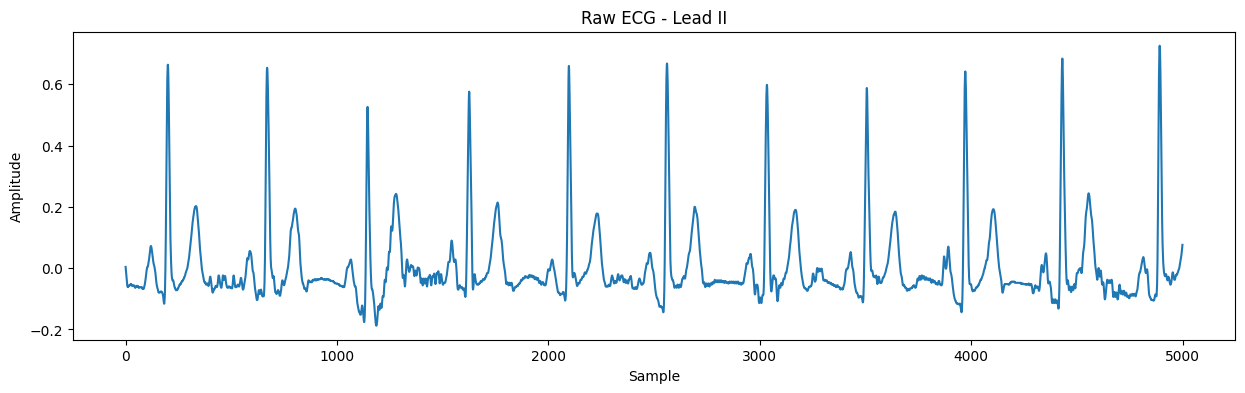

Shape: torch.Size([12, 5000])
Mean: 8.107424065428859e-08
Std: 1.0000083446502686
Min: -6.048690319061279
Max: 7.5613532066345215


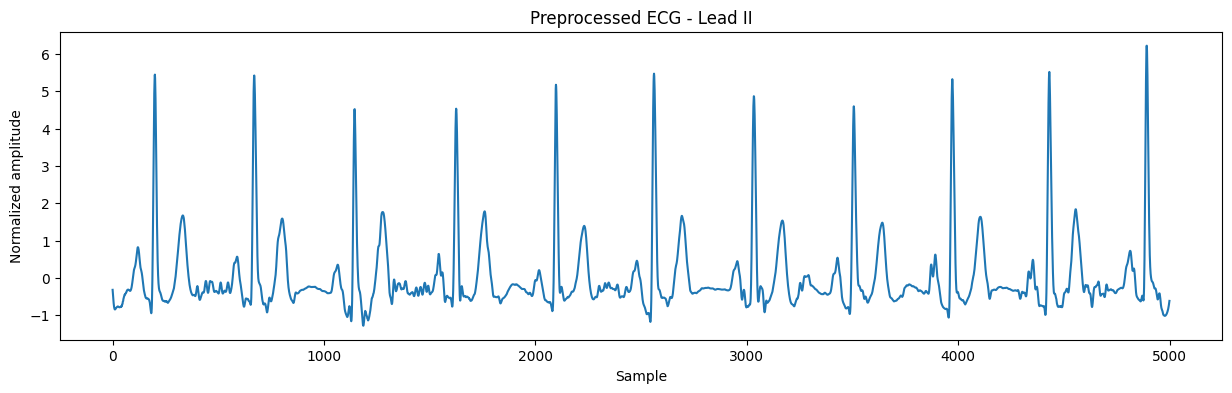

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(raw[1])

plt.title("Raw ECG - Lead II")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()
ecg = preprocess_ecg(record)

print("Shape:", ecg.shape)
print("Mean:", ecg.mean().item())
print("Std:", ecg.std().item())
print("Min:", ecg.min().item())
print("Max:", ecg.max().item())
plt.figure(figsize=(15, 4))

plt.plot(ecg[1].numpy())

plt.title("Preprocessed ECG - Lead II")
plt.xlabel("Sample")
plt.ylabel("Normalized amplitude")

plt.show()

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ACS19955Dataset(Dataset):

    def __init__(self, df, ecg_dir):
        self.df = df.reset_index(drop=True)
        self.ecg_dir = ecg_dir

        self.label_columns = [
            'AMI', 'OMI', 'CTO', 'PCI', 'NSTEMI', 'STEMI', 'UA',
            'LM', 'PLAD', 'MLAD', 'DLAD', 'DB',
            'PLCX', 'MLCX', 'DLCX', 'OM',
            'PRCA', 'MRCA', 'DRCA',
            'VF_VT', 'Paced', 'Prior_PCI'
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # ECG filename
        filename = row['ecg_row_record']
        record_name = os.path.join(
            self.ecg_dir,
            os.path.splitext(filename)[0]
        )

        # Preprocess ECG
        ecg = preprocess_ecg(record_name)

        # Labels
        labels = torch.tensor(
            row[self.label_columns].values.astype(np.float32)
        )

        return ecg, labels

In [ ]:
train_dataset = ACS19955Dataset(
    train_df,
    ecg_dir
)

print("Number of ECGs:", len(train_dataset))

Number of ECGs: 17960


In [ ]:
ecg, labels = train_dataset[0]

print("ECG shape:", ecg.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

ECG shape: torch.Size([12, 5000])
Labels shape: torch.Size([22])
Labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [ ]:
label_counts = train_df[
    train_dataset.label_columns
].sum().sort_values(ascending=False)

print(label_counts)

UA           6213
PCI          4541
AMI          2679
STEMI        1442
Prior_PCI    1323
NSTEMI       1235
OMI          1151
CTO           957
VF_VT         869
PLAD          838
PRCA          720
MRCA          456
PLCX          400
DRCA          357
Paced         338
MLAD          332
DLCX          255
MLCX          226
DB             89
OM             53
DLAD           44
LM             13
dtype: int64


In [ ]:
label_percent = (
    label_counts / len(train_df) * 100
).round(2)

print(label_percent)

UA           34.59
PCI          25.28
AMI          14.92
STEMI         8.03
Prior_PCI     7.37
NSTEMI        6.88
OMI           6.41
CTO           5.33
VF_VT         4.84
PLAD          4.67
PRCA          4.01
MRCA          2.54
PLCX          2.23
DRCA          1.99
Paced         1.88
MLAD          1.85
DLCX          1.42
MLCX          1.26
DB            0.50
OM            0.30
DLAD          0.24
LM            0.07
dtype: float64


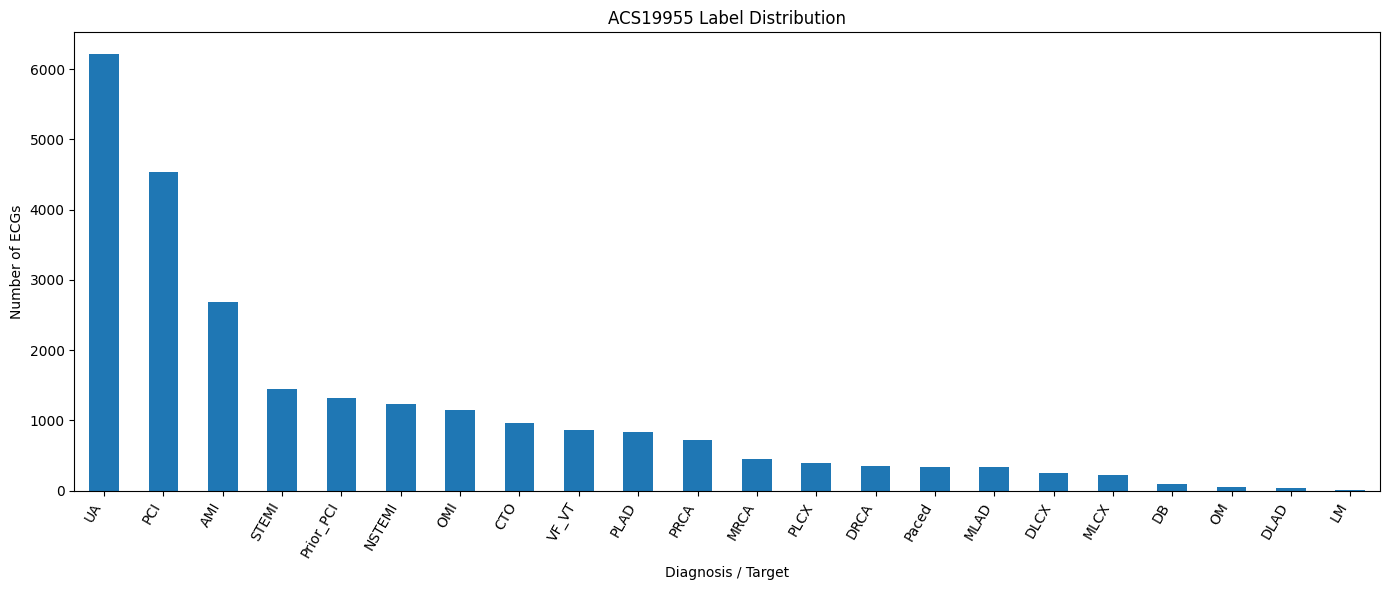

In [ ]:
plt.figure(figsize=(14, 6))

label_counts.plot(kind="bar")

plt.ylabel("Number of ECGs")
plt.xlabel("Diagnosis / Target")
plt.title("ACS19955 Label Distribution")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import wfdb
from tqdm import tqdm

acs_dir = "/content/drive/MyDrive/ECG_Project/ACS19955"

ecg_dir = os.path.join(
    acs_dir,
    "ECG_row_data",
    "row_data"
)

processed_dir = os.path.join(
    acs_dir,
    "preprocessed"
)

os.makedirs(processed_dir, exist_ok=True)

print("Processed data will be saved to:")
print(processed_dir)

Processed data will be saved to:
/content/drive/MyDrive/ECG_Project/ACS19955/preprocessed


In [ ]:
SHARD_SIZE = 500

print("ECGs per shard:", SHARD_SIZE)

ECGs per shard: 500


In [ ]:
label_columns = [
    'AMI', 'OMI', 'CTO', 'PCI', 'NSTEMI', 'STEMI', 'UA',
    'LM', 'PLAD', 'MLAD', 'DLAD', 'DB',
    'PLCX', 'MLCX', 'DLCX', 'OM',
    'PRCA', 'MRCA', 'DRCA',
    'VF_VT', 'Paced', 'Prior_PCI'
]

metadata = train_df[
    ['Patient_id', 'ecg_row_record'] + label_columns
].copy()

metadata.to_csv(
    os.path.join(processed_dir, "train_metadata.csv"),
    index=False
)

print(metadata.shape)

(17960, 24)


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

train_metadata = train_df[
    ['Patient_id', 'ecg_row_record'] + label_columns
].copy()

test_metadata = test_df[
    ['Patient_id', 'ecg_row_record']
].copy()

train_metadata.to_csv(
    os.path.join(processed_dir, "train_metadata.csv"),
    index=False
)

test_metadata.to_csv(
    os.path.join(processed_dir, "test_metadata.csv"),
    index=False
)

print("Train metadata:", train_metadata.shape)
print("Test metadata :", test_metadata.shape)

Train metadata: (17960, 24)
Test metadata : (1995, 2)


In [ ]:
train_processed_dir = os.path.join(processed_dir, "train")
test_processed_dir = os.path.join(processed_dir, "test")

os.makedirs(train_processed_dir, exist_ok=True)
os.makedirs(test_processed_dir, exist_ok=True)

print("Directories ready.")

Directories ready.


In [ ]:
def preprocess_and_save_shards(
    df,
    output_dir,
    shard_size=500,
    start_shard=0
):

    os.makedirs(output_dir, exist_ok=True)

    total = len(df)

    num_shards = (total + shard_size - 1) // shard_size

    failed_records = []

    print("Total ECGs:", total)
    print("Total shards:", num_shards)
    print("Starting from shard:", start_shard)

    for shard_idx in range(start_shard, num_shards):

        # ------------------------------------------------
        # Skip shard if it already exists
        # ------------------------------------------------

        shard_path = os.path.join(
            output_dir,
            f"shard_{shard_idx:03d}.npy"
        )

        index_path = os.path.join(
            output_dir,
            f"shard_{shard_idx:03d}_indices.npy"
        )

        if os.path.exists(shard_path) and os.path.exists(index_path):

            print(f"Shard {shard_idx} already exists → skipping")
            continue

        # ------------------------------------------------
        # Determine rows belonging to this shard
        # ------------------------------------------------

        start = shard_idx * shard_size
        end = min(start + shard_size, total)

        shard_ecgs = []
        valid_indices = []

        print(
            f"\nProcessing shard {shard_idx} "
            f"(rows {start} → {end-1})"
        )

        # ------------------------------------------------
        # Process ECGs
        # ------------------------------------------------

        for idx in tqdm(
            range(start, end),
            desc=f"Shard {shard_idx}"
        ):

            filename = str(
                df.iloc[idx]["ecg_row_record"]
            )

            record_name = os.path.splitext(filename)[0]

            record_path = os.path.join(
                ecg_dir,
                record_name
            )

            try:

                ecg = preprocess_ecg(record_path)

                shard_ecgs.append(ecg)

                # IMPORTANT:
                # Store original dataframe index
                valid_indices.append(idx)

            except Exception as e:

                print(
                    f"\n⚠️ Skipping {filename}"
                )

                print("Reason:", str(e))

                failed_records.append({
                    "index": idx,
                    "file": filename,
                    "error": str(e)
                })

        # ------------------------------------------------
        # Save successful ECGs
        # ------------------------------------------------

        if len(shard_ecgs) > 0:

            shard_ecgs = np.stack(shard_ecgs)

            valid_indices = np.array(
                valid_indices,
                dtype=np.int32
            )

            np.save(
                shard_path,
                shard_ecgs
            )

            np.save(
                index_path,
                valid_indices
            )

            print(
                f"✅ Saved shard {shard_idx}"
            )

            print(
                "ECGs:",
                shard_ecgs.shape
            )

            print(
                "Indices:",
                valid_indices.shape
            )

        else:

            print(
                f"❌ No valid ECGs in shard {shard_idx}"
            )

    # ----------------------------------------------------
    # Save failed-record log
    # ----------------------------------------------------

    failed_path = os.path.join(
        output_dir,
        "failed_records.csv"
    )

    if failed_records:

        failed_df = pd.DataFrame(
            failed_records
        )

        failed_df.to_csv(
            failed_path,
            index=False
        )

        print(
            f"\n⚠️ Failed records saved to:"
        )

        print(failed_path)

        print(
            "Total failed:",
            len(failed_records)
        )

    else:

        print(
            "\n✅ No failed ECGs encountered."
        )

In [ ]:
# preprocess_and_save_shards(
#     train_df,
#     train_processed_dir,
#     shard_size=500,
#     start_shard=16
# )

In [ ]:
# test_processed_dir = "/content/drive/MyDrive/ECG_Project/ACS19955/preprocessed/test"

# os.makedirs(test_processed_dir, exist_ok=True)

# print(test_processed_dir)

# preprocess_and_save_shards(
#     test_df,
#     test_processed_dir,
#     shard_size=500,
#     start_shard=0
# )

In [ ]:
import glob
import os
import numpy as np

shards = sorted([
    f for f in glob.glob(
        train_processed_dir + "/shard_*.npy"
    )
    if "_indices" not in f
])

print("Number of shards:", len(shards))

total_ecgs = 0

for f in shards:
    data = np.load(f, mmap_mode="r")
    print(os.path.basename(f), data.shape)
    total_ecgs += data.shape[0]

print("\nTotal processed ECGs:", total_ecgs)
print("Original training ECGs:", len(train_df))
print("Missing:", len(train_df) - total_ecgs)

Number of shards: 36
shard_000.npy (500, 12, 5000)
shard_001.npy (500, 12, 5000)
shard_002.npy (500, 12, 5000)
shard_003.npy (500, 12, 5000)
shard_004.npy (500, 12, 5000)
shard_005.npy (500, 12, 5000)
shard_006.npy (500, 12, 5000)
shard_007.npy (500, 12, 5000)
shard_008.npy (500, 12, 5000)
shard_009.npy (500, 12, 5000)
shard_010.npy (500, 12, 5000)
shard_011.npy (500, 12, 5000)
shard_012.npy (500, 12, 5000)
shard_013.npy (500, 12, 5000)
shard_014.npy (500, 12, 5000)
shard_015.npy (500, 12, 5000)
shard_016.npy (499, 12, 5000)
shard_017.npy (500, 12, 5000)
shard_018.npy (500, 12, 5000)
shard_019.npy (500, 12, 5000)
shard_020.npy (500, 12, 5000)
shard_021.npy (500, 12, 5000)
shard_022.npy (500, 12, 5000)
shard_023.npy (500, 12, 5000)
shard_024.npy (500, 12, 5000)
shard_025.npy (500, 12, 5000)
shard_026.npy (500, 12, 5000)
shard_027.npy (500, 12, 5000)
shard_028.npy (500, 12, 5000)
shard_029.npy (499, 12, 5000)
shard_030.npy (500, 12, 5000)
shard_031.npy (500, 12, 5000)
shard_032.npy (500,

In [ ]:
# ============================================================
# REPAIR MISSING SHARD INDEX FILES
# ============================================================

import os
import numpy as np

train_dir = "/content/drive/MyDrive/ECG_Project/ACS19955/preprocessed/train"

# Original dataset indices that failed during preprocessing
failed_indices = {8428, 14724}

# Total original training records
num_original_records = len(train_df)

# ------------------------------------------------------------
# Reconstruct the sequence of successfully processed indices
# ------------------------------------------------------------

successful_indices = [
    i
    for i in range(num_original_records)
    if i not in failed_indices
]

print("Original records :", num_original_records)
print("Failed records   :", len(failed_indices))
print("Successful ECGs  :", len(successful_indices))


# ------------------------------------------------------------
# Walk through every saved shard
# ------------------------------------------------------------

shard_files = sorted([
    f for f in os.listdir(train_dir)
    if f.startswith("shard_")
    and f.endswith(".npy")
    and "_indices" not in f
])

print("\nNumber of ECG shards:", len(shard_files))


cursor = 0

for shard_file in shard_files:

    shard_path = os.path.join(
        train_dir,
        shard_file
    )

    # Load only shape information
    shard = np.load(
        shard_path,
        mmap_mode="r"
    )

    shard_length = shard.shape[0]

    # Determine which original dataset rows belong
    # to this shard
    shard_indices = successful_indices[
        cursor : cursor + shard_length
    ]

    index_file = shard_file.replace(
        ".npy",
        "_indices.npy"
    )

    index_path = os.path.join(
        train_dir,
        index_file
    )

    # Only create missing index files
    if not os.path.exists(index_path):

        np.save(
            index_path,
            np.array(
                shard_indices,
                dtype=np.int64
            )
        )

        print(
            f"Created {index_file}: "
            f"{len(shard_indices)} indices"
        )

    else:

        print(
            f"Already exists: {index_file}"
        )

    cursor += shard_length


# ------------------------------------------------------------
# Final check
# ------------------------------------------------------------

print("\n" + "=" * 60)

print(
    "Total mapped ECGs:",
    cursor
)

print(
    "Expected ECGs:",
    len(successful_indices)
)

print("=" * 60)

assert cursor == len(successful_indices)

print("INDEX REPAIR COMPLETE ✅")

Original records : 17960
Failed records   : 2
Successful ECGs  : 17958

Number of ECG shards: 36
Created shard_000_indices.npy: 500 indices
Created shard_001_indices.npy: 500 indices
Created shard_002_indices.npy: 500 indices
Created shard_003_indices.npy: 500 indices
Created shard_004_indices.npy: 500 indices
Created shard_005_indices.npy: 500 indices
Created shard_006_indices.npy: 500 indices
Created shard_007_indices.npy: 500 indices
Created shard_008_indices.npy: 500 indices
Created shard_009_indices.npy: 500 indices
Created shard_010_indices.npy: 500 indices
Created shard_011_indices.npy: 500 indices
Created shard_012_indices.npy: 500 indices
Created shard_013_indices.npy: 500 indices
Created shard_014_indices.npy: 500 indices
Created shard_015_indices.npy: 500 indices
Already exists: shard_016_indices.npy
Already exists: shard_017_indices.npy
Already exists: shard_018_indices.npy
Already exists: shard_019_indices.npy
Already exists: shard_020_indices.npy
Already exists: shard_021